In [168]:
import re
import numpy as np
import pandas as pd
from tqdm import tqdm
import country_converter as coco
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import shap

c:\Users\SemKj\Downloads\fundamentals_of_data_science\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [161]:
df = pd.read_parquet("../final_clean.csv")

In [162]:
total_len = len(df)
print(f"totals len: {total_len}\n")

over_5_pct = []
under_or_equal_5_pct = []

# Group columns by missing threshold
for col in df.columns:
    missing_num = df[col].isnull().sum()
    if missing_num > 0:
        missing_pct = (missing_num / total_len) * 100
        item = (col, missing_num, missing_pct)
        if missing_pct > 15.0:
            over_5_pct.append(item)
        else:
            under_or_equal_5_pct.append(item)

# 1. Print columns with > 5% missing
print("=== Columns with MORE than 5% missing ===")
if over_5_pct:
    for col, count, pct in over_5_pct:
        print(f"Missing {col} num: {count} / {total_len} ({pct:.2f}%)")
else:
    print("None\n")

print("\n=== Columns with 5% or LESS missing ===")
if under_or_equal_5_pct:
    for col, count, pct in under_or_equal_5_pct:
        print(f"Missing {col} num: {count} / {total_len} ({pct:.2f}%)")
else:
    print("None")

totals len: 438425

=== Columns with MORE than 5% missing ===
Missing side_a_2nd num: 357275 / 438425 (81.49%)
Missing side_b_2nd num: 415773 / 438425 (94.83%)
Missing iso3_a_2nd num: 357275 / 438425 (81.49%)
Missing iso3_b num: 416900 / 438425 (95.09%)
Missing iso3_b_2nd num: 415773 / 438425 (94.83%)
Missing side_b_ideals_diff num: 420285 / 438425 (95.86%)
Missing side_b_dist num: 417975 / 438425 (95.34%)
Missing territory_name num: 199208 / 438425 (45.44%)
Missing ep_end_date num: 353102 / 438425 (80.54%)
Missing ep_end_prec num: 438425 / 438425 (100.00%)
Missing bdeadlow num: 176499 / 438425 (40.26%)
Missing bdeadhig num: 176499 / 438425 (40.26%)
Missing bdeadbes num: 270581 / 438425 (61.72%)
Missing annualdata num: 176499 / 438425 (40.26%)
Missing source num: 176499 / 438425 (40.26%)
Missing bdversion num: 176499 / 438425 (40.26%)
Missing location_prio num: 176499 / 438425 (40.26%)
Missing incomp num: 176499 / 438425 (40.26%)
Missing terr num: 296890 / 438425 (67.72%)
Missing int n

In [163]:
# Calculate percentage of missing values per column
missing_pct = (df.isnull().sum() / len(df)) * 100

# Get list of column names with less than 15% missing
cols_under_15_pct = missing_pct[missing_pct < 15.0].index.tolist()

print("Columns with < 15% missing values:")
df = df[cols_under_15_pct].dropna()

Columns with < 15% missing values:


In [164]:
df = df[['country_code', 'conflict_id', 'year',  'has_conflict_mention',
      'intensity_level', 'cumulative_intensity', 'type_of_conflict',
       'main_actor', 'secondary_actor','conflict_host', 
       'side_a_ideals_diff', 'side_a_dist', 'incompatibility',
        'deaths_estimate']]

In [ ]:
# 1. Feature Definition & Type Standardization
id_cols = ['conflict_id', 'year']
target_col = 'has_conflict_mention'

categorical_cols = ['type_of_conflict', 'incompatibility', 'country_code']
bool_cols = ['main_actor', 'secondary_actor', 'conflict_host']
numeric_cols = ['intensity_level', 'cumulative_intensity', 'side_a_ideals_diff', 
                'side_a_dist', 'deaths_estimate']

feature_cols = list(dict.fromkeys(categorical_cols + bool_cols + numeric_cols))

df = fin.loc[:, ~fin.columns.duplicated()].copy()
df[target_col] = df[target_col].astype(int)

for col in bool_cols:
    df[col] = df[col].astype(int)

for col in categorical_cols:
    df[col] = df[col].astype(str).astype('category')

# 2. Setup Rolling Window Parameters
start_eval_year = 2012   # First year to test on
end_eval_year = df['year'].max()

cv_results = []

print(f"Starting Walk-Forward CV from year {start_eval_year} to {end_eval_year}...\n")

# 3. Rolling Origin Loop
for test_year in range(start_eval_year, end_eval_year + 1):
    # Train on all history UP TO test_year - 1
    train_mask = df['year'] < test_year
    test_mask = df['year'] == test_year
    
    train_df = df[train_mask]
    test_df = df[test_mask]
    
    # Skip fold if test year has no target instances or missing data
    if len(test_df) == 0 or test_df[target_col].nunique() < 2:
        continue
        
    X_tr, y_tr = train_df[feature_cols], train_df[target_col]
    X_te, y_te = test_df[feature_cols], test_df[target_col]
    
    # Calculate scale_pos_weight dynamically per fold
    num_neg = (y_tr == 0).sum()
    num_pos = (y_tr == 1).sum()
    scale_weight = num_neg / num_pos if num_pos > 0 else 1.0
    
    # Initialize XGBoost Classifier
    model = xgb.XGBClassifier(
        objective='binary:logistic',
        tree_method='hist',
        enable_categorical=True,
        scale_pos_weight=scale_weight,
        n_estimators=300,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(X_tr, y_tr, verbose=False)
    
    # Predict probabilities for current test_year
    probs = model.predict_proba(X_te)[:, 1]
    
    # Evaluate performance
    roc_auc = roc_auc_score(y_te, probs)
    precision, recall, _ = precision_recall_curve(y_te, probs)
    pr_auc = auc(recall, precision)

    # 2. Binary Class Predictions & Threshold-based Metrics
    preds = (probs >= threshold).astype(int)
    
    prec = precision_score(y_te, preds, zero_division=0)
    rec = recall_score(y_te, preds, zero_division=0)
    f2 = fbeta_score(y_te, preds, beta=2, zero_division=0)
    brier = brier_score_loss(y_te, probs)
    
    # 3. Store in Results List
    cv_results.append({
        'Test Year': test_year,
        'Train Size': len(train_df),
        'Test Size': len(test_df),
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Precision': prec,
        'Recall': rec,
        'F2-Score': f2,
        'Brier Score': brier
    })
    
    print(f"Year {test_year} | Train N: {len(train_df):6d} | Test N: {len(test_df):5d} | ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")

# 4. Aggregate CV Performance
results_df = pd.DataFrame(cv_results)
print("\n=== Walk-Forward Cross-Validation Summary ===")
print(results_df[['ROC-AUC', 'PR-AUC']].describe().T[['mean', 'std', 'min', '50%', 'max']])

Starting Walk-Forward CV from year 2012 to 2025...

Year 2012 | Train N: 205730 | Test N:  5490 | ROC-AUC: 0.8117 | PR-AUC: 0.4170
Year 2013 | Train N: 211220 | Test N:  6516 | ROC-AUC: 0.7978 | PR-AUC: 0.4638
Year 2014 | Train N: 217736 | Test N:  7826 | ROC-AUC: 0.7731 | PR-AUC: 0.4135
Year 2015 | Train N: 225562 | Test N:  9595 | ROC-AUC: 0.8187 | PR-AUC: 0.3876
Year 2016 | Train N: 235157 | Test N:  9464 | ROC-AUC: 0.8397 | PR-AUC: 0.4166
Year 2017 | Train N: 244621 | Test N:  9200 | ROC-AUC: 0.7805 | PR-AUC: 0.4320
Year 2018 | Train N: 253821 | Test N:  9016 | ROC-AUC: 0.7903 | PR-AUC: 0.3568
Year 2019 | Train N: 262837 | Test N:  9882 | ROC-AUC: 0.8284 | PR-AUC: 0.3706
Year 2020 | Train N: 272719 | Test N:  9466 | ROC-AUC: 0.8470 | PR-AUC: 0.2667
Year 2021 | Train N: 282185 | Test N:  9289 | ROC-AUC: 0.7877 | PR-AUC: 0.2679
Year 2022 | Train N: 291474 | Test N:  9727 | ROC-AUC: 0.7526 | PR-AUC: 0.2290
Year 2023 | Train N: 301201 | Test N: 10213 | ROC-AUC: 0.7714 | PR-AUC: 0.2173


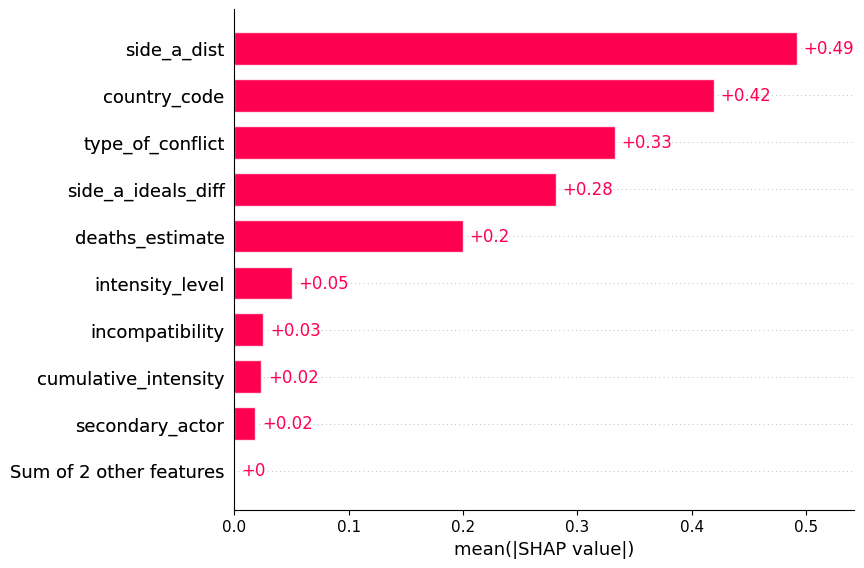

In [178]:
# 2. Compute SHAP values natively inside XGBoost C++ core
# Convert X_test into DMatrix (handles categorical types automatically)
dtest = xgb.DMatrix(X_test, enable_categorical=True)

# pred_contribs=True returns SHAP matrix of shape (n_samples, n_features + 1)
shap_contribs = model.get_booster().predict(dtest, pred_contribs=True)

# Separate feature SHAP values from the base expected value (last column)
shap_values_matrix = shap_contribs[:, :-1]
base_value = shap_contribs[0, -1]

# 3. Create a SHAP Explanation object for rich plotting compatibility
explanation = shap.Explanation(
    values=shap_values_matrix,
    base_values=base_value,
    data=X_test,
    feature_names=feature_cols
)

# 4. Plot Global Importance Bar Chart
plt.figure(figsize=(10, 6))
shap.plots.bar(explanation)
plt.show()

